In [1]:
%matplotlib inline
%load_ext autoreload
%autoreload 2

In [2]:
import os
import sys
import gepard as g # NeuralModel with Dispersion relation added 
from gepard import model, fitter, data, plots
import gepard.plots as gplot
from gepard.fits import GLO15new, AUTIpts, ALUIpts, ACpts, AULpts, ALLpts, H_AULpts, H1ZEUS, CLAS08pts
print('Gepard version = {}'.format(g.__version__))

Gepard version = 0.9.11b0


In [3]:
import gmaster as gm
from gmaster.fits import th_KM15, th_KM10b, par_KM15, par_KM15 # need KM15 for simulated data
th15 = th_KM15
from gmaster.constants import Mp2, toTeX

In [4]:
import torch
import torch.nn as nn
import numpy as np 
#np.set_printoptions(legacy='1.25')
import matplotlib
import matplotlib.pyplot as plt
import shelve, logging, copy
logging.basicConfig(level=logging.ERROR) 
import pandas as pd 
from scipy.integrate import quad
from scipy.interpolate import InterpolatedUnivariateSpline
from scipy.stats import norm
from pathlib import Path

In [5]:
class KM15(gm.eff.KellyEFF, gm.gpd.PWNormGPD, gm.cff.HybridFreePoleCFF, gm.dvcs.BM10tw2):

    pass

th_KM15_H = KM15()
th_KM15_H.parameters.update(par_KM15)
th_KM15_H.parameters.update({'trv':0, 'rpi':0})
th_KM15_H.name = 'KM15_H'

In [6]:
th_KM15_H.print_CFFs(g.dset[101][0])

 ImH =  6.74
 ReH = -2.97
 ImE =  0.00
 ReE =  2.39
ImHt =  0.00
ReHt =  0.00
ImEt =  0.00
ReEt =  0.00



# Datasets 

In [7]:
sys.path.append('/Users/higuera-admin/Documents/Programs/ldrdgff/gepard/src/gepard/')

import mydatafiles
from mydatafiles import ep2epgamma

mydset = g.data.loaddata(mydatafiles)
mydset.update(g.data.loaddata(ep2epgamma))

In [8]:
# To have nice LaTeX fonts on plots
plt.rc('text', usetex=False)
params = {'text.latex.preamble' : '\n'.join([r'\usepackage{amssymb}', r'\usepackage{amsmath}'])}
plt.rcParams.update(params)

In [9]:
############ Defining fitpoints ############
# HALL A 
HallA15_XLUw = g.dset.get(117,[])
HallA15w = g.dset.get(117,[]) + g.dset.get(116,[])[:15] + g.dset.get(116,[])[15:] # 2015(BSDw+BSSw)
HallA17w = g.dset.get(135,[]) + g.dset.get(136,[])[:22] + g.dset.get(136,[])[22:] # 2017(BSDw+BSSw)
HallA6w = g.dset.get(50, []) + g.dset.get(51, []) + g.dset.get(105, []) # 2006(BSDw_byDM+BSSw+BSDovBSS)
HALLAg = HallA15_XLUw + HallA15w + HallA17w
# CLAS 
CLASold = g.dset.get(101, []) + g.dset.get(102, []) + g.dset.get(8, []) + g.dset.get(81, []) + g.dset.get(94, []) + g.dset.get(95, []) + g.dset.get(96, [])
CLAS23 = mydset.get(150, [])
CLAS18XUUw = g.select(mydset.get(162, []), criteria=['FTn == 0']) + g.select(mydset.get(162, []), criteria=['FTn == 1']) + g.select(mydset.get(162, []), criteria=['FTn == 2'])
CLAS18XLU = mydset.get(165, [])
CLAS18 = CLAS18XUUw + CLAS18XLU
CLAS25XUU = g.select(mydset.get(167, []), criteria=['FTn == 0']) #+ g.select(mydset.get(167, []), criteria=['FTn == 1']) #+ g.select(mydset.get(167, []), criteria=['FTn == 2'])
# HERMES
HERMES = ALUIpts + ACpts + H_AULpts + ALLpts + AUTIpts

In [10]:
fitpoints = (
	g.dset.get(101, []) + g.dset.get(102, []) #+ g.dset.get(8, [])
    #CLASold + CLAS18 #+ CLAS23 # + mydset.get(182, []) + mydset.get(192, []) #cFT
    #+ CLAS25XUU
    #+ HERMES
	#+ mydset.get(251, [])  # CLAS_TSA
	#+ HALLAg 
	#+ H1ZEUS	# HERA
)
g.describe_data(fitpoints)

npt x obs     collab  FTn    id  ref.        
----------------------------------------------
48 x XLUw    CLAS    -1     101 arXiv:1504.02009
48 x XUUw    CLAS    0.0    102 arXiv:1504.02009
48 x XUUw    CLAS    1.0    102 arXiv:1504.02009
----------------------------------------------
TOTAL = 144


In [11]:
ts = [pt.t for pt in fitpoints]
print("Min t:", min(ts), "Max t:", max(ts))

Min t: -0.45 Max t: -0.11


# Custom Neural Models 2 and 4 CFFs

In [12]:
import torch.nn as nn
class CustomNetwork(nn.Module):
    def __init__(self):
        super(CustomNetwork, self).__init__()

        # Define the layers for the network

        # ImH network part
        self.n1 = nn.Linear(3, 23)  # 2 input features, 12 hidden units
        self.n2 = nn.Linear(23, 37)  # 12 hidden units, 17 hidden units
        self.n3 = nn.Linear(37, 1)  # 7 hidden units, 1 output features
        
        # D-term network part
        self.n1p = nn.Linear(1, 12)  # 2 input features, 12 hidden units
        self.n2p = nn.Linear(12, 10)  # 12 hidden units, 17 hidden units
        self.n3p = nn.Linear(10, 1)  # 17 hidden units, 1 output features

        # Parameters for the physics-motivated envelope
        #self._init_subtraction_negative()  # Initialize only the D-term network weights with a small negative bias
        self.M2 = 1.0**2
        self.alpha = 3.0  # Could be a learnable parameter too

    '''def _init_subtraction_negative(self):
        """Initialize only the D-term network weights with a small negative bias."""
        for layer in [self.n1p, self.n2p, self.n3p]:
            if isinstance(layer, nn.Linear):
                nn.init.normal_(layer.weight, mean=-0.02, std=0.01)
                if layer.bias is not None:
                    nn.init.constant_(layer.bias, -0.02) 
                #print(f"Initial weights for {layer}: {layer.weight.data[:5]}")    '''

    def forward(self, x):
        
       
        x0 = x
        
        # Build Im network
        x = torch.relu(self.n1(x0))
        x = torch.relu(self.n2(x))
        output1 = self.n3(x)
        
        # Build D network (only uses t = x[:,1])
        # build the input tensor
        x0_1 = torch.cat((x0[:,1].unsqueeze(1),), dim=0)   
        x2 = torch.relu(self.n1p(x0_1))
        x2 = torch.relu(self.n2p(x2))
        output2 = self.n3p(x2)
        #print("Raw t (x0_1):", x0_1[:5].flatten().tolist())

        # Physical envelope sahpe factor ( (1 + (-t)/M²)^-3 ) (comment if not needed)
        #eps = 1e-5
        #envelope = torch.pow(torch.clamp(1 + x0_1 / self.M2, min=eps), -self.alpha)
        #output2_phys = output2 * envelope
        #output2 *= envelope
        
        
        #concatenate outputs
        output = torch.cat((output1, output2), dim=1)
       
        return output 

In [13]:
class NNTest_DR(g.model.NeuralModel_DR, g.eff.KellyEFF, g.dvcs.BM10tw2, g.cff.DispersionCFF):
    
    def build_net(self):
        '''Overriding the default architecture and optimizer'''
        nn_model = CustomNetwork()
        optimizer = torch.optim.Rprop(nn_model.parameters(),
                lr=0.01)
        return nn_model, optimizer
    
    def subtraction(self, pt): #This should use the NN, the real part will be calculated by the CFF_Dispersion methods
        """Subtraction constant."""
        #refer to the location of D in output layer (defined in the next cell)
        xi = pt.xB / (2 - pt.xB)
        return self.cffs(1, pt, xi) #/ pt.xB**self.xpow

        ''' input_layer = torch.tensor([[pt.xB, pt.t, pt.Q2]], dtype=torch.float32)

        mean = self.nn_mean.clone()
        std = self.nn_std.clone()

        # Cancel xB and Q2 influence
        mean[0, 0] = 0.0  # xB
        std[0, 0] = 1.0
        mean[0, 2] = 0.0  # Q²
        std[0, 2] = 1.0

        x = self.standardize(input_layer, mean, std)

        return self.nn_model(x)[0, self.cffs_map['D']] '''
    
    def ImH(self, pt, xi=0) -> float:
        """Return Im(CFF H) for kinematic point."""
        #refer to the location of Im H in output layer (defined in the next cell)
        return self.cffs(0, pt, xi)
    
    def ImE(self, pt, xi=0):
        """Return Im(CFF E) for kinematic point."""
        return self.zero(pt)
    
    def ImHt(self, pt, xi=0):
        """Return Im(CFF Ht) for kinematic point."""
        return self.zero(pt)
    
    def ImEt(self, pt, xi=0):
        """Return Im(CFF Et) for kinematic point."""
        return self.zero(pt)

## 4 CFFs

In [14]:
import torch.nn as nn
class CustomNetwork_4(nn.Module):
    def __init__(self):
        super(CustomNetwork_4, self).__init__()

        # Define the layers for the network
        self.n1 = nn.Linear(3, 25)  # 2 input features, 7 hidden units
        self.n2 = nn.Linear(25, 37)  # 7 hidden units, 7 hidden units
        self.n3 = nn.Linear(37, 2)  # 7 hidden units, 2 output features
        
        self.n1p = nn.Linear(1, 7)  # 2 input features, 7 hidden units
        self.n2p = nn.Linear(7, 5)  # 7 hidden units, 7 hidden units
        self.n3p = nn.Linear(5, 1)  # 7 hidden units, 2 output features

    def forward(self, x):
        
       
        x0 = x
        
        # Build Im network
        x = torch.relu(self.n1(x0))
        x = torch.relu(self.n2(x))
        output1 = self.n3(x)
        
        # Build D network
        # build the input tensor
        x0_1 = torch.cat((x0[:,1].unsqueeze(1),), dim=0)
       
        x2 = torch.relu(self.n1p(x0_1))
        x2 = torch.relu(self.n2p(x2))
        output2 = self.n3p(x2)
        
        #concatenate outputs
        output = torch.cat((output1, output2), dim=1)
       
        return output 

In [15]:
class NNTest_DR_4(g.model.NeuralModel_DR, g.eff.DipoleEFF, g.dvcs.BM10tw2, g.cff.DispersionCFF):
    
    def build_net(self):
        '''Overriding the default architecture and optimizer'''
        nn_model = CustomNetwork_4()
        optimizer = torch.optim.Rprop(nn_model.parameters(),
                lr=0.05) # lr=0.01
        return nn_model, optimizer
    
    def subtraction(self, pt): #This should use the NN, the real part will be calculated by the CFF_Dispersion methods
        """Subtraction constant."""
        #print("I am here in D")
        xi = pt.xB / (2 - pt.xB)
        #refer to the location of D in output layer (defined in the next cell)
        return self.cffs(2, pt, xi)
    
    def ImH(self, pt, xi=0) -> float:
        """Return Im(CFF H) for kinematic point."""
        #refer to the location of Im H in output layer (defined in the next cell)
        return self.cffs(0, pt, xi)
    
    def ImE(self, pt, xi=0):
        """Return Im(CFF E) for kinematic point."""
        return self.cffs(1, pt, xi)
    
    def ImHt(self, pt, xi=0):
        """Return Im(CFF Ht) for kinematic point."""
        return self.zero(pt)
    
    def ImEt(self, pt, xi=0):
        """Return Im(CFF Et) for kinematic point."""
        return self.zero(pt)

# Fits

In [16]:
th = NNTest_DR(output_layer=['ImH', 'D'], q2in=True)#'ImH', 'ReH', 'ImE', 'ReE', 'ImHt', 'ReHt', 'ImEt', 'ReEt'])#

In [18]:
import time
t0 = time.time()
f = g.fitter.NeuralFitter(fitpoints, th, nnets=3, nbatch=10, batchlen=2, regularization='L2', lx_lambda=0.001)
f.fit()
t1 = time.time()                  
# time in minutes
print(f"Total time: {(t1 - t0) / 60:.2f} minutes")


Epoch   2: train error = 3.4624 test error = 4.9844 -
Epoch   4: train error = 3.1144 test error = 4.2943 -
Epoch   6: train error = 2.4141 test error = 3.1739 -
Epoch   8: train error = 1.4884 test error = 1.8699 -
Epoch  10: train error = 1.2559 test error = 2.0072 +
Epoch  12: train error = 1.1315 test error = 1.8869 +
Epoch  14: train error = 1.0880 test error = 1.8695 -
Epoch  16: train error = 1.0687 test error = 1.7934 -
Epoch  18: train error = 1.0303 test error = 1.6919 -
Epoch  20: train error = 1.0002 test error = 1.7392 +Net 0 --> test_err = 1.691897947871246

Epoch   2: train error = 5.4030 test error = 5.5085 -
Epoch   4: train error = 4.4248 test error = 5.0418 -
Epoch   6: train error = 3.9939 test error = 4.0229 -
Epoch   8: train error = 2.8453 test error = 2.5476 -
Epoch  10: train error = 1.5662 test error = 1.8207 -
Epoch  12: train error = 1.5093 test error = 1.5267 -
Epoch  14: train error = 1.3462 test error = 1.6000 +
Epoch  16: train error = 1.2674 test error

In [19]:
print(th.chisq(fitpoints))

(np.float64(55.37244750491369), 144, np.float64(0.9999999999982742))


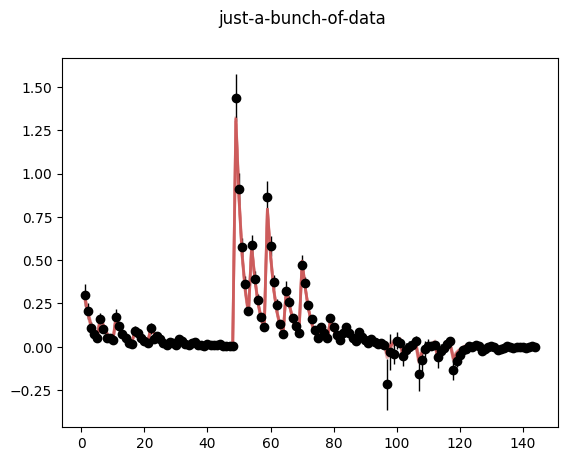

In [20]:
fig = gplot.jbod(points=fitpoints, lines=[th], bands=[th])

In [21]:
th.subtraction(fitpoints[0])* 18. / 25., th_KM15_H.subtraction(fitpoints[0])* 18. / 25.

(tensor([-0.3748], grad_fn=<DivBackward0>), 1.721685307875536)

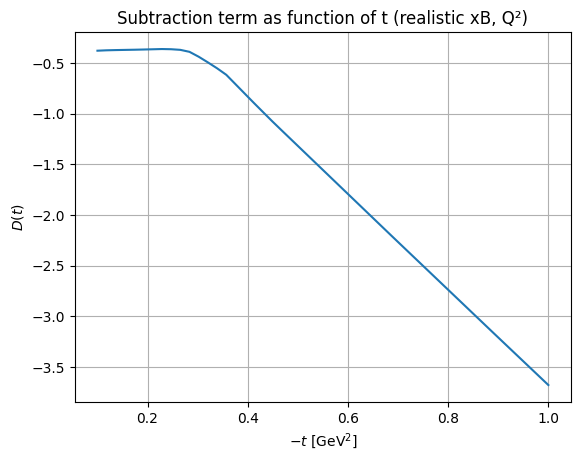

In [24]:
class DummyPoint:
    def __init__(self, t, xB=0.2, Q2=1.8):
        self.t = float(-t)   
        self.tm = t    
        self.xB = xB
        self.Q2 = Q2

# Rehacer plot con DummyPoints realistas
ts = torch.linspace(0.1, 1.0, 50)
d_vals = [th.subtraction(DummyPoint(t)).detach().numpy()* 18. / 25. for t in ts]

plt.plot(ts, d_vals)
plt.xlabel(r'$-t$ [GeV$^2$]')
plt.ylabel(r'$D(t)$')
plt.title("Subtraction term as function of t (realistic xB, Q²)")
plt.grid()
plt.show()

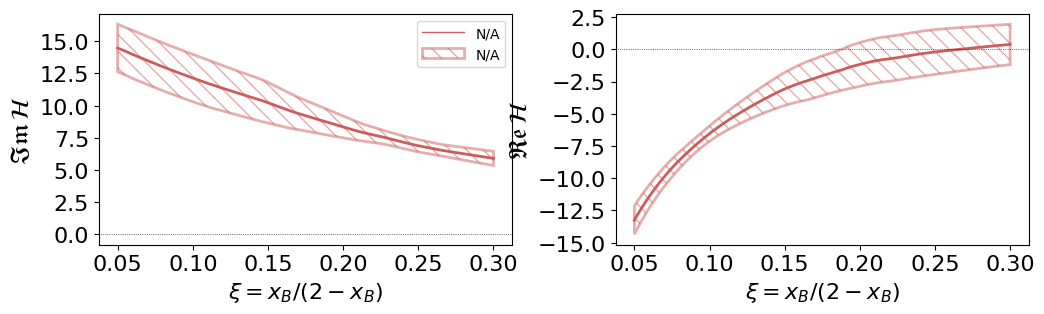

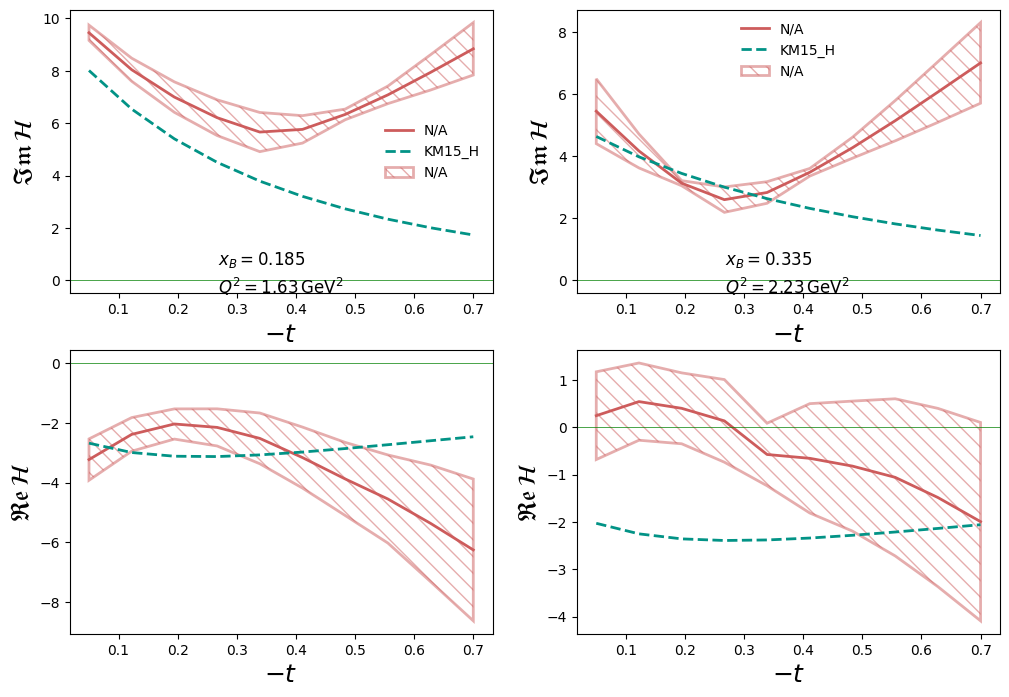

In [23]:
fig = gplot.CFF3(cffs=['ImH', 'ReH'],  lines=[th], bands=[th])
fig = gplot.CFFt(cffs=['ImH', 'ReH'], lines=[th, th_KM15_H], bands=[th])

# Fit 4 CFFs

In [ ]:
th2 = NNTest_DR_4(output_layer=['ImH', 'ImE', 'D'], q2in=True)

In [ ]:
import time
t0 = time.time()
# f = g.fitter.NeuralFitter(fitpoints, th2, nnets=5, nbatch=10, batchlen=2, regularization='L2', lx_lambda=0.01)
f = g.fitter.NeuralFitter(fitpoints, th2, nnets=5, nbatch=10, batchlen=10, regularization='L2', lx_lambda=0.002)
f.fit()

t1 = time.time()
# time in minutes
print(f"Total time: {(t1 - t0) / 60:.2f} minutes")


Epoch  10: train error = 8.5925 test error = 8.9688 -
Epoch  20: train error = 7.2385 test error = 6.1362 -
Epoch  30: train error = 6.2944 test error = 4.8267 -
Epoch  40: train error = 5.8503 test error = 4.3718 -
Epoch  50: train error = 5.6052 test error = 4.1545 -
Epoch  60: train error = 5.4515 test error = 4.1982 +
Epoch  70: train error = 5.3143 test error = 4.0935 -
Epoch  80: train error = 5.2401 test error = 3.8993 -
Epoch  90: train error = 5.1810 test error = 3.8425 -
Epoch 100: train error = 5.1445 test error = 3.7609 -Net 0 --> test_err = 3.7609490186477177

Epoch  10: train error = 8.6635 test error = 8.6966 -
Epoch  20: train error = 6.0931 test error = 6.7568 -
Epoch  30: train error = 4.9672 test error = 5.9159 -
Epoch  40: train error = 4.6073 test error = 5.7838 -
Epoch  50: train error = 4.4158 test error = 5.5614 -
Epoch  60: train error = 4.2944 test error = 5.4771 -
Epoch  70: train error = 4.2148 test error = 5.4241 -
Epoch  80: train error = 4.1583 test erro

In [ ]:
th2.chisq(fitpoints)

(np.float64(3238.9086732619157), 998, np.float64(0.0))

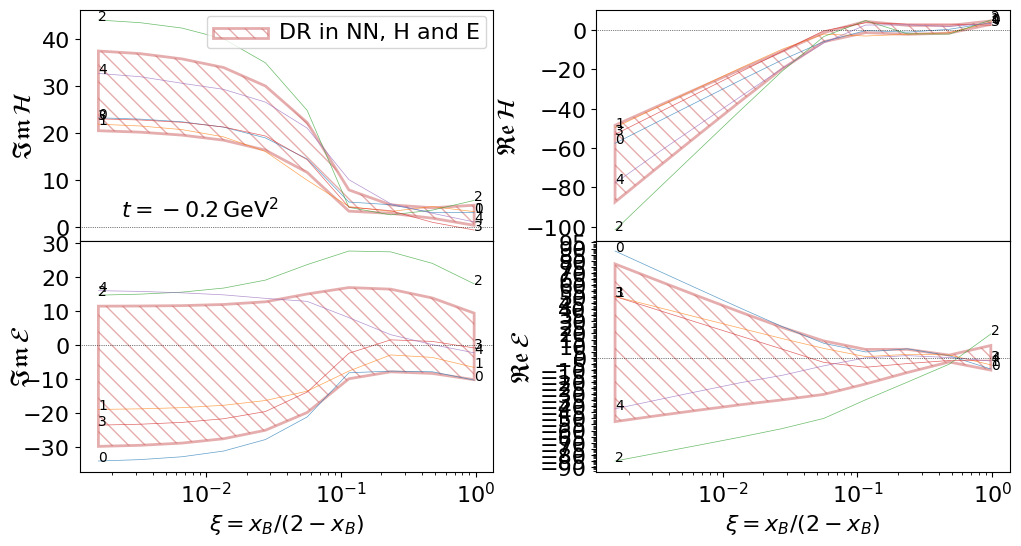

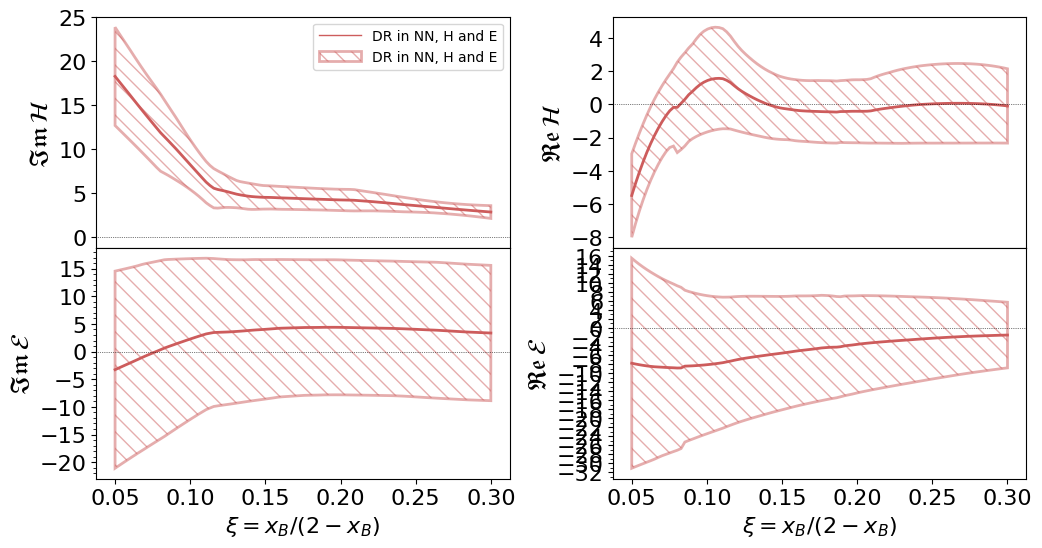

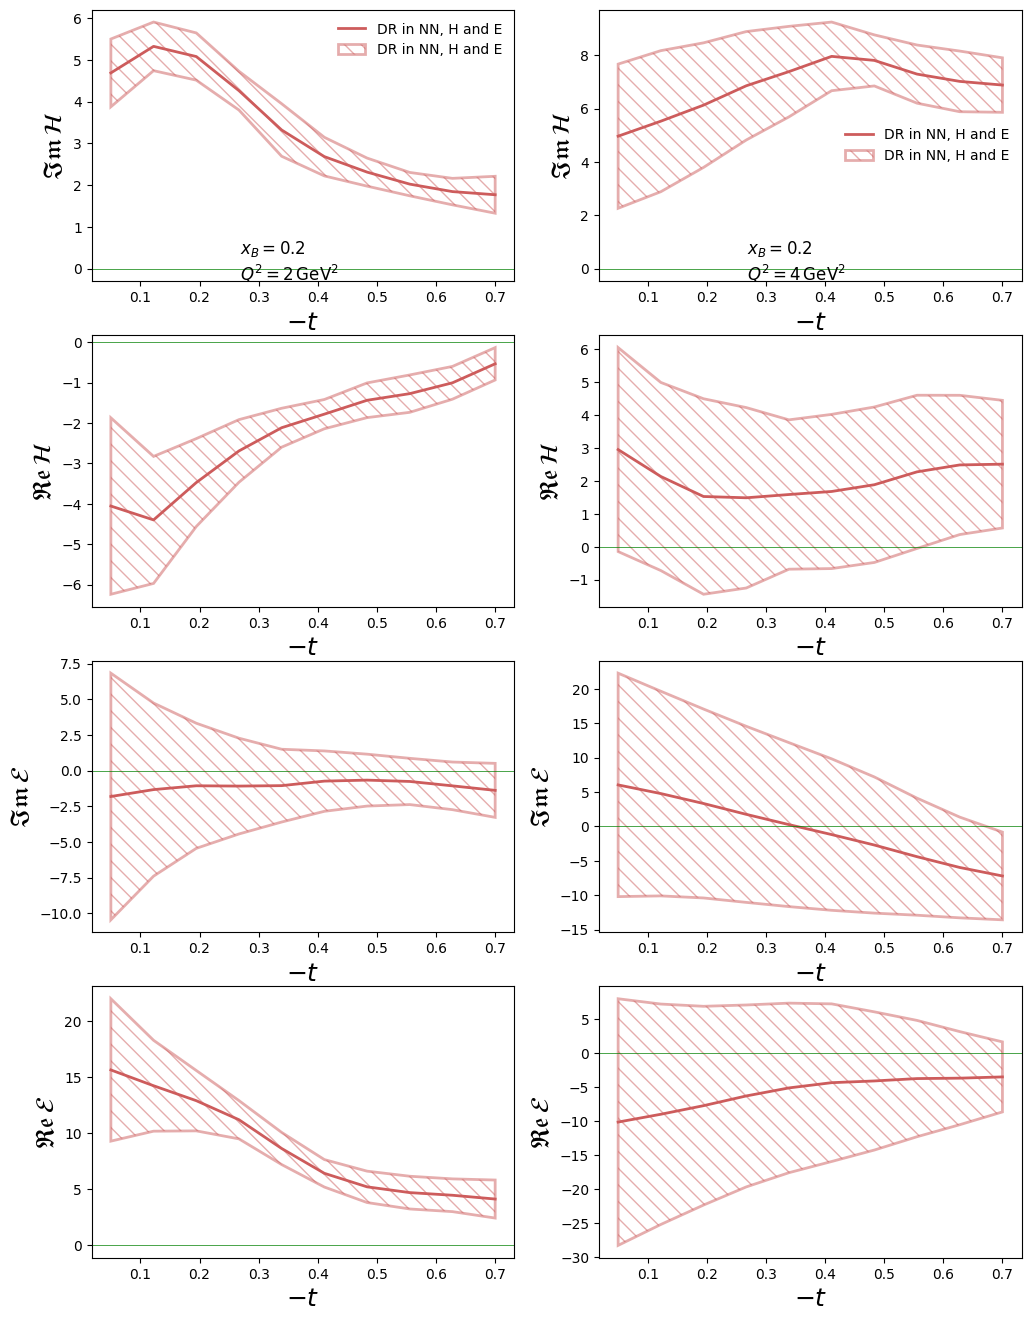

In [ ]:
th2.name = "DR in NN, H and E"
fig = gplot.CFF3log(cffs=['ImH', 'ReH', 'ImE', 'ReE'],  mesh=th2, bands=[th2], tval=-0.2)
fig = gplot.CFF3(cffs=['ImH', 'ReH', 'ImE', 'ReE'],  lines=[th2], bands=[th2]) #mesh=th2, #lines=[th, th2, th3], bands=[th, th2, th3]
fig = gplot.CFFt(cffs=['ImH', 'ReH', 'ImE', 'ReE'],  lines=[th2], bands=[th2])  #lines=[th, th2, th3], bands=[th, th2, th3]

# D-term

In [ ]:
import random
ptts = []
tm_list = np.linspace(0.1, 1.0, 10)#[0.1, 0.2, 0.3, 0.4]

for tm in tm_list:
    #rndm_idx = random.randint(0, len(tm_list)-1) # take some random point and set/change -t
    ptb = g.dset[102][0].copy()  
    ptb.t = -tm
    ptb.tm = tm
    th15.prepare(ptb)
    ptts.append(ptb)


print(ptts)

[DataPoint: XUUw = 1.437, DataPoint: XUUw = 1.437, DataPoint: XUUw = 1.437, DataPoint: XUUw = 1.437, DataPoint: XUUw = 1.437, DataPoint: XUUw = 1.437, DataPoint: XUUw = 1.437, DataPoint: XUUw = 1.437, DataPoint: XUUw = 1.437, DataPoint: XUUw = 1.437]


In [ ]:
D = []
std_values = [] #!
net_indices = [] #!
for th in [th]: #, th2
    print("\n---- [{} - {}] ----".format(th.name, th.description))
    A = []
    for pt in ptts[::-1]:
        Ds = []
        for i, net in enumerate(th.nets):  # Loop over neural networks
            th.nn_model, th.nn_mean, th.nn_std = net  # Assign neural net parameters
            
            Ds.append(float(th.m.subtraction(pt).detach().numpy()*18./25.))
            #print(float(-th.m.subtraction(pt).detach().numpy()*18./25.))
            th.cffs_evaluated = False
        net_indices.append(i)
        #for k in range(len(th.m.nets)):
            #th.m.parameters['nnet'] = k
            # NOTE: subtraction in code is equal to -\Delta(t) !
            #Ds.append(-th.m.subtraction(pt).detach().numpy()*18./25.) 
            #print(-th.m.subtraction(pt).detach().numpy()*18./25.)
        Ds = np.array(Ds)
        D_std = Ds.std() #!
        std_values.append(D_std) #!

        print("{}, {}: {} +- {}".format(pt.xB, pt.t, Ds.mean(), Ds.std()))
        A.append((pt.tm, Ds.mean(), Ds.std()))
    th.m.parameters['nnet'] = 'ALL'    
    D.append(A)


---- [N/A - N/A] ----
0.185, -1.0: 7.550198597527924e-06 +- 4.349499953190647e-06
0.185, -0.9: 1.0769188975245925e-05 +- 6.17896061967603e-06
0.185, -0.8: 1.6093545855255798e-05 +- 9.195070748037033e-06
0.185, -0.7000000000000001: 2.5487168568361084e-05 +- 1.4554772604188854e-05
0.185, -0.6: 4.3783232467831115e-05 +- 2.4871025615491976e-05
0.185, -0.5: 8.352536242455244e-05 +- 4.785673919945781e-05
0.185, -0.4: 0.0001870484142273199 +- 0.0001137700469043366
0.185, -0.30000000000000004: 0.0005875233182450756 +- 0.00038387951114924706
0.185, -0.2: 0.004181884159334004 +- 0.002911346171299327
0.185, -0.1: 6337838348.705613 +- 12675644793.669582


/var/folders/qr/2k2591d90wjb4sqtmlttw7r40000gq/T/ipykernel_76424/3466570253.py:12: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  Ds.append(float(th.m.subtraction(pt).detach().numpy()*18./25.))


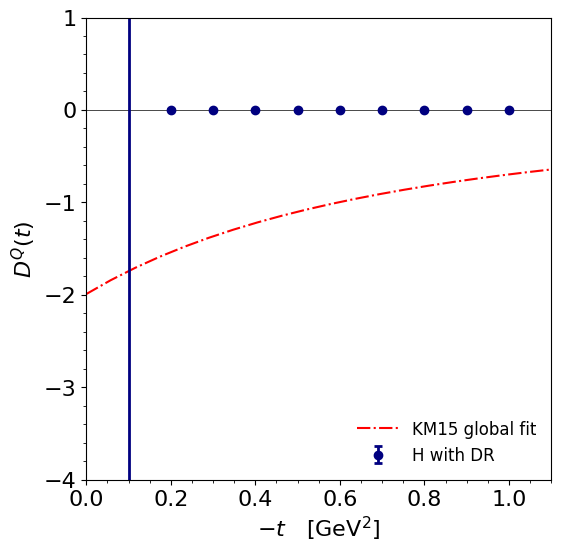

In [ ]:
NPTS = 20
ts = np.linspace(0, 1.1, NPTS)
KMS = np.array([-(18./25.)*2.768/(1.+tm/1.204**2)**2 for tm in ts])
CDS = np.array(D[0])
#CADS = np.array(D[1])

fig, ax = plt.subplots(1, 1,  figsize=[6,6])
ax.axhline(y=0, linewidth=0.5, color='k')  # y=0 thin line
ax.plot(ts, KMS, 'r-.', label='KM15 global fit')
ax.errorbar(CDS[:,0], CDS[:,1], CDS[:,2], linestyle='None', color='navy',
            elinewidth=2, capsize=3, capthick=2, marker='o', label='H with DR')
#ax.errorbar(CADS[:,0,]+0.01, CADS[:,1], CADS[:,2], linestyle='None', elinewidth=2,
#            capsize=3, capthick=2, marker='o', color='indianred', label='H and E with DR')

ax.set_xlim(0.0, 1.1)
ax.set_ylim(-4.0, 1)
ax.legend(loc=4, handlelength=2.5,
            prop=matplotlib.font_manager.FontProperties(size="large")
        ).draw_frame(0)
ax.set_xlabel(r'$-t \quad [{\rm GeV}^2]$', fontsize=16)
ax.set_ylabel(r'$D^{Q}(t)$', fontsize=16)
ax.tick_params(axis='both', which='major', labelsize=16)
ax.tick_params(axis='both', which='minor', labelsize=16)
ax.xaxis.set_major_locator(
        matplotlib.ticker.MultipleLocator(0.2)) 
ax.xaxis.set_minor_locator(
        matplotlib.ticker.MultipleLocator(0.05)) 
ax.yaxis.set_major_locator(
        matplotlib.ticker.MultipleLocator(1.)) 
ax.yaxis.set_minor_locator(
        matplotlib.ticker.MultipleLocator(0.2)) 

In [ ]:
for th in [th]: #, th2
    print("\n---- [{} - {}] ----".format(th.name, th.description))
    for i, net in enumerate(th.nets):
        th.nn_model, th.nn_mean, th.nn_std = net
        print(f"Net {i}, D(t=0.6) = {th.subtraction(DummyPoint(0.6))}")


---- [DR in NN, H and E - N/A] ----
Net 0, D(t=0.6) = tensor([-0.1231], grad_fn=<MulBackward0>)
Net 1, D(t=0.6) = tensor([-2.2445], grad_fn=<MulBackward0>)
Net 2, D(t=0.6) = tensor([-0.0463], grad_fn=<MulBackward0>)
Net 3, D(t=0.6) = tensor([-0.1529], grad_fn=<MulBackward0>)
Net 4, D(t=0.6) = tensor([-1.3475], grad_fn=<MulBackward0>)

---- [DR in NN, H and E - N/A] ----
Net 0, D(t=0.6) = tensor([-0.1231], grad_fn=<MulBackward0>)
Net 1, D(t=0.6) = tensor([-2.2445], grad_fn=<MulBackward0>)
Net 2, D(t=0.6) = tensor([-0.0463], grad_fn=<MulBackward0>)
Net 3, D(t=0.6) = tensor([-0.1529], grad_fn=<MulBackward0>)
Net 4, D(t=0.6) = tensor([-1.3475], grad_fn=<MulBackward0>)


In [ ]:
for th in [th]: # , th2
    print("\n---- [{} - {}] ----".format(th.name, th.description))
    for xb in [0.1, 0.2, 0.4, 0.6]:
        pt = DummyPoint(t=-0.3)
        pt.xB = xb
        pt.Q2 = 1.0
        print(f"xB = {xb} → D(t=-0.4) = {th.subtraction(pt).item():.4f}")


---- [DR in NN, H and E - N/A] ----
xB = 0.1 → D(t=-0.4) = -4.0395
xB = 0.2 → D(t=-0.4) = -4.0395
xB = 0.4 → D(t=-0.4) = -4.0395
xB = 0.6 → D(t=-0.4) = -4.0395

---- [DR in NN, H and E - N/A] ----
xB = 0.1 → D(t=-0.4) = -4.0395
xB = 0.2 → D(t=-0.4) = -4.0395
xB = 0.4 → D(t=-0.4) = -4.0395
xB = 0.6 → D(t=-0.4) = -4.0395
